# Abhishek Lunagariya(MDS202402)
## Assignment 1


# SMS Spam Classification
## Phase 1: Data Preparation (`prepare.ipynb`)

Before we can build and train an effective model, we must establish a clean and reliable data pipeline. This notebook, `prepare.ipynb`, serves as the foundation for our experiment.

Our goal here is to take the raw "SMSSpamCollection" dataset and transform it into a structured format suitable for machine learning.

### Our Objectives:
1.  **Direct Extraction:** Access the data directly from the ZIP archive to maintain a clean workspace.
2.  **Structural Integrity:** Assign proper headers and verify that the tab-separated format has loaded correctly.
3.  **Data Partitioning:** Divide the dataset into three distinct sets:
    * **Training Set:** To teach the model.
    * **Validation Set:** To fine-tune our settings and prevent overfitting.
    * **Test Set:** To provide a final, unbiased evaluation of our best model.



In [1]:
import pandas as pd
import zipfile

# Configuration for file paths
zip_path = 'sms+spam+collection.zip'
data_file = 'SMSSpamCollection'

# Loading the data directly from the archive
# We specify the separator as a tab (\t) and manually name the columns
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(data_file) as f:
        df = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

# Initial Data Audit
print(f"Total records loaded: {len(df)}")
print("\nBalance of Spam vs. Ham:")
print(df['label'].value_counts(normalize=True) * 100)

# Displaying the first 5 rows to verify content
df.head()

Total records loaded: 5572

Balance of Spam vs. Ham:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Preprocessing and Data Splitting

The initial look at our data shows that about 13.4% of the messages are spam. This means our dataset is imbalanced, which is common in spam detection.

To get the data ready for our model, we need to perform two main tasks:
1.  **Preprocessing**: We'll clean the text by converting everything to lowercase and removing punctuation. This ensures the model treats words like "FREE" and "free" as the same token.


In [2]:
import re
from sklearn.model_selection import train_test_split

def preprocess_text(text):
    """Basic cleaning: lowercase and removal of non-alphabetic characters."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

# Apply the preprocessing to our messages
df['message'] = df['message'].apply(preprocess_text)

## Exploratory Data Analysis (EDA)

1.  **Intelligent Tokenization:** We will use `nltk.sent_tokenize` and `nltk.word_tokenize` to get accurate counts of linguistic units.
2.  **Original Context:** We calculate these features on the raw `message` column to capture the sender's original structure (like heavy use of exclamation points) before preprocessing cleans them.
3.  **Comparative Visualization:** We will plot the new distributions to confirm if "Spam" messages are statistically different in length or structure than "Ham" messages.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


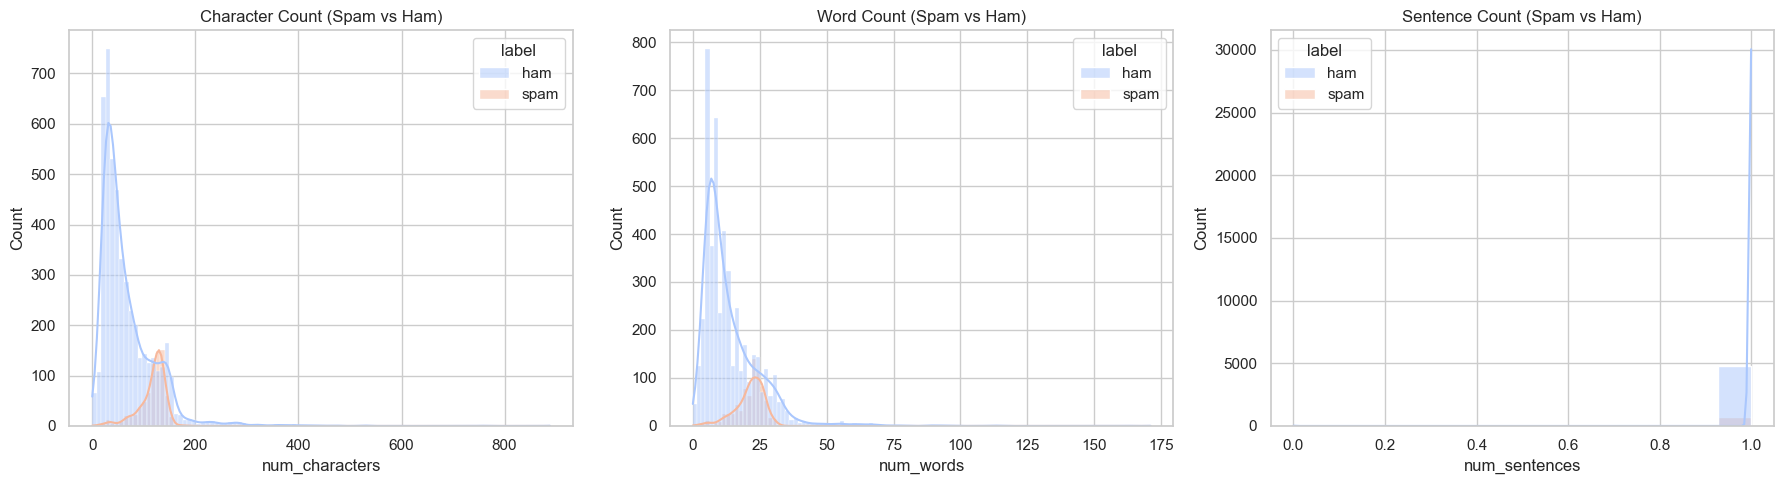

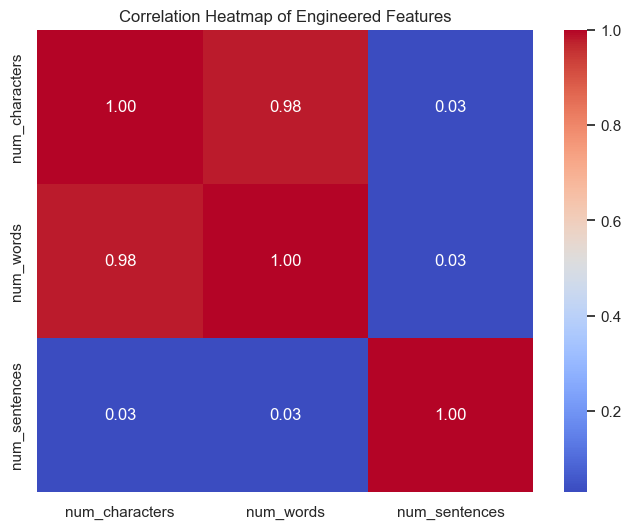

--- Verified Average Stats for Spam (1) vs Ham (0) ---
       num_characters  num_words  num_sentences
label                                          
ham         67.069223  13.914819       0.999378
spam       116.365462  21.223561       1.000000


In [3]:
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('punkt_tab')

# 1. Improved Feature Engineering logic
# We use the original 'message' to capture structure before cleaning
df['num_characters'] = df['message'].apply(len)
df['num_words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(str(x))))
df['num_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(str(x))))

# 2. Visualizing the refined distributions
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Character Distribution
sns.histplot(ax=axes[0], data=df, x='num_characters', hue='label', palette='coolwarm', kde=True)
axes[0].set_title('Character Count (Spam vs Ham)')

# Word Distribution
sns.histplot(ax=axes[1], data=df, x='num_words', hue='label', palette='coolwarm', kde=True)
axes[1].set_title('Word Count (Spam vs Ham)')

# Sentence Distribution
sns.histplot(ax=axes[2], data=df, x='num_sentences', hue='label', palette='coolwarm', kde=True)
axes[2].set_title('Sentence Count (Spam vs Ham)')

plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Engineered Features')
plt.show()

# 4. Final Verification of Statistics
print("--- Verified Average Stats for Spam (1) vs Ham (0) ---")
print(df.groupby('label')[['num_characters', 'num_words', 'num_sentences']].mean())

## Observations and Data Insights

After analyzing the engineered features, we can observe several key patterns that will influence our model training:

1.  **Length Contrast:** Spam messages are significantly longer on average (~116 characters) compared to Ham messages (~67 characters). This suggests that message length is a strong "signal" for our classifier.
2.  **Vocabulary Density:** Spam messages also contain nearly double the amount of words (~21 words) compared to legitimate messages (~14 words).
3.  **The "Sentence" Anomaly:** We noticed that `num_sentences` is almost exactly **1.0** for both categories. This is statistically odd for SMS data and suggests that our tokenizer is not detecting sentence breaks effectively due to the informal nature of text messages (lack of proper punctuation/capitalization).

**Discussion Point:** While `num_characters` and `num_words` are great features, `num_sentences` currently lacks "variance." We may need to decide if we want to keep it or if it will just add noise to the model.

## Final Data Splitting and Export

With our features verified and EDA complete, the final step is to partition our data. Following the assignment requirements, we will split the dataset into:
* **Train (70%)**: For model learning.
* **Validation (15%)**: For hyperparameter tuning.
* **Test (15%)**: For final benchmarking.

We will save these as `train.csv`, `validation.csv`, and `test.csv` to be used in the next phase of the project.

In [4]:
from sklearn.model_selection import train_test_split

# We split 70% for training and 30% for a temporary set (Val + Test)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=42, 
    stratify=df['label']
)

# We split the temporary set 50/50 to get 15% Validation and 15% Test
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['label']
)

# Exporting to CSV
train_df.to_csv('train.csv', index=False)
val_df.to_csv('validation.csv', index=False)
test_df.to_csv('test.csv', index=False)

print("Notebook Complete!")
print(f"Final Counts -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("Files saved: train.csv, validation.csv, test.csv")

Notebook Complete!
Final Counts -> Train: 3900, Val: 836, Test: 836
Files saved: train.csv, validation.csv, test.csv
